# TabPFN for Uplift Modeling with Meta-Learners

This notebook evaluates whether TabPFN can improve uplift modeling performance when used inside meta-learners (S-learner, T-learner, X-learner) compared to traditional models.

**Dataset**: IHDP (Infant Health and Development Program)

**Meta-learners to test**:
- **S-learner**: Single model predicting outcome with treatment as feature
- **T-learner**: Two separate models for treatment and control groups
- **X-learner**: Two-stage approach that imputes counterfactual outcomes and uses propensity-weighted CATE estimates
- **R-learner**
- **DR-Learner**

## 1. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor, LGBMClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from tabpfn import TabPFNRegressor, TabPFNClassifier
from tabpfn_extensions.hpo import TunedTabPFNRegressor, TunedTabPFNClassifier
from tabicl import TabICLRegressor, TabICLClassifier
import matplotlib.pyplot as plt
from econml.metalearners import SLearner, TLearner, XLearner
from econml.dml import NonParamDML, CausalForestDML
from econml.dr import DRLearner
from sklearn.metrics import mean_squared_error
import warnings
import torch
import tabpfn
try:
    from causalpfn import CATEEstimator
except ImportError:
    print("CausalPFN not installed. Please install with: pip install causalpfn")
print(tabpfn.__version__)

# Detect device
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f"Using device: {device}")

# CausalPFN does not support MPS
causalpfn_device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"CausalPFN device: {causalpfn_device}")

# TabICL does not support MPS
tabicl_device = "cpu" if device == "mps" else device
print(f"TabICL device: {tabicl_device}")

HPO_N_TRIALS = 20  # Bayesian HPO trials for TunedTabPFN

# Set random seed for reproducibility
np.random.seed(42)

# Suppress warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message=".*feature names.*")

import os
os.environ["PYTHONWARNINGS"] = "ignore::UserWarning"


/opt/miniconda3/lib/python3.13/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


6.2.0
Using device: mps
CausalPFN device: cpu
TabICL device: cpu


## 2. Define Models, Tuning, and Metrics

We define LightGBM hyperparameter tuning functions (using `RandomizedSearchCV`) and evaluation metrics. LightGBM is tuned **once per dataset** — the best hyperparameters are then reused across all meta-learners for that dataset.

In [2]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, KFold
from sklearn.metrics import mean_squared_error
import numpy as np

LGBM_GRID = {
    'num_leaves':        [15, 31, 63],
    'min_child_samples': [20, 50, 100],
    'learning_rate': [0.01, 0.05, 0.1],
}
N_ITER = 15  # RandomizedSearchCV draws
N_EST = 1000 # trees used for final refit


# ── Core tuner (pooled data — for S, R, DR learners) ─────────────────────────
def _tune_reg(X, y, stratify, grid, n_iter=N_ITER, n_estimators_search=N_EST, 
              n_estimators_final=N_EST, seed=42):
    # Search with fewer trees — faster CV
    X = np.asarray(X)
    base = LGBMRegressor(n_estimators=n_estimators_search, random_state=seed, verbose=-1)
    cv = list(StratifiedKFold(n_splits=3, shuffle=True, random_state=seed).split(X, stratify))
    Search = RandomizedSearchCV if n_iter else GridSearchCV
    kw = dict(n_iter=n_iter, random_state=seed) if n_iter else {}
    search = Search(base, grid, scoring='neg_mean_squared_error', cv=cv, n_jobs=-1, **kw)
    search.fit(X, y)
    
    # Refit best params with full number of trees
    best_params = search.best_params_
    final_model = LGBMRegressor(n_estimators=n_estimators_final, random_state=seed, 
                                 verbose=-1, **best_params)
    final_model.fit(X, y)
    return final_model
def _tune_cls(X, t, grid, n_iter=N_ITER, n_estimators_search=N_EST,
              n_estimators_final=N_EST, seed=42):
    X = np.asarray(X)
    base = LGBMClassifier(n_estimators=n_estimators_search, random_state=seed, verbose=-1)
    cv = list(StratifiedKFold(n_splits=3, shuffle=True, random_state=seed).split(X, t))
    Search = RandomizedSearchCV if n_iter else GridSearchCV
    kw = dict(n_iter=n_iter, random_state=seed) if n_iter else {}
    search = Search(base, grid, scoring='neg_log_loss', cv=cv, n_jobs=-1, **kw)
    search.fit(X, t)
    
    best_params = search.best_params_
    final_model = LGBMClassifier(n_estimators=n_estimators_final, random_state=seed,
                                  verbose=-1, **best_params)
    final_model.fit(X, t)
    return final_model

def _tune_reg_arm(X_arm, y_arm, grid, n_iter=N_ITER, n_estimators_search=N_EST,
                  n_estimators_final=N_EST, seed=42):
    X_arm = np.asarray(X_arm)
    n_splits = min(3, max(2, len(y_arm) // 20))
    base = LGBMRegressor(n_estimators=n_estimators_search, random_state=seed, verbose=-1)
    cv = list(KFold(n_splits=n_splits, shuffle=True, random_state=seed).split(X_arm))
    Search = RandomizedSearchCV if n_iter else GridSearchCV
    kw = dict(n_iter=n_iter, random_state=seed) if n_iter else {}
    search = Search(base, grid, scoring='neg_mean_squared_error', cv=cv, n_jobs=-1, **kw)
    search.fit(X_arm, y_arm)
    
    best_params = search.best_params_
    final_model = LGBMRegressor(n_estimators=n_estimators_final, random_state=seed,
                                 verbose=-1, **best_params)
    final_model.fit(X_arm, y_arm)
    return final_model


from econml.utilities import WeightedModelWrapper#

def make_lgbm_final(seed=42):#
    """Fresh GridSearchCV for R/DR final stage — fits on pseudo-outcomes, not nuisance."""
    return GridSearchCV(
        LGBMRegressor(n_estimators=N_EST, random_state=seed, verbose=-1),
        LGBM_GRID,
        cv=3, scoring='neg_mean_squared_error', n_jobs=-1
    )

def make_tabpfn_final():#
    """WeightedModelWrapper lets TabPFN accept sample_weight in R-learner final stage."""
    return WeightedModelWrapper(TabPFNRegressor(device=device))

def make_tabicl_final():
    """WeightedModelWrapper lets TabICL accept sample_weight in R-learner final stage."""#
    return WeightedModelWrapper(TabICLRegressor(device=tabicl_device, random_state=42, verbose=False))#



def _extract(model, grid):
    """Pull only the searched params (+ n_estimators) out of a fitted estimator."""
    p = model.get_params()
    keys = set(grid.keys()) | {'n_estimators'}
    return {k: p[k] for k in keys if k in p}

def make_reg(params, seed=42):
    return LGBMRegressor(random_state=seed, verbose=-1, **params)

def make_cls(params, seed=42):
    return LGBMClassifier(random_state=seed, verbose=-1, **params)


# ── Metric functions ──────────────────────────────────────────────────────────
def calculate_pehe(predicted_ite, true_ite):
    return np.sqrt(mean_squared_error(true_ite, predicted_ite))

def calculate_ate_error(predicted_ite, true_ite):
    return np.abs(predicted_ite.mean() - true_ite.mean())


## 3. Data Loading (IHDP 1-100)

We load 100 realizations of the IHDP dataset from local `.npz` files and store them for evaluation.

In [3]:
from collections import defaultdict

# Store results for all runs
# Structure: results[meta_learner][base_model][metric] = list of values
all_results = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

# Load IHDP data from local npz files (100 replications)
train_data = np.load('ihdp_npci_1-100.train.npz')
test_data = np.load('ihdp_npci_1-100.test.npz')

n_datasets = 5
processed_datasets = []
feature_names = [f"x{j}" for j in range(25)]

print(f"Loading {n_datasets} replications from local IHDP files...")

for i in range(n_datasets):
    X_train = pd.DataFrame(train_data['x'][:, :, i], columns=feature_names)
    T_train = train_data['t'][:, i]
    Y_train = train_data['yf'][:, i]
    mu0_train = train_data['mu0'][:, i]
    mu1_train = train_data['mu1'][:, i]

    X_test = pd.DataFrame(test_data['x'][:, :, i], columns=feature_names)
    T_test = test_data['t'][:, i]
    Y_test = test_data['yf'][:, i]
    mu0_test = test_data['mu0'][:, i]
    mu1_test = test_data['mu1'][:, i]

    true_ITE_test = mu1_test - mu0_test

    processed_datasets.append({
        'id': i + 1,
        'X_train': X_train,
        'X_test': X_test,
        'T_train': T_train,
        'T_test': T_test,
        'Y_train': Y_train,
        'Y_test': Y_test,
        'true_ITE_test': true_ITE_test
    })

print(f"Loaded {len(processed_datasets)} replications.")
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}, Features: {X_train.shape[1]}")

Loading 5 replications from local IHDP files...
Loaded 5 replications.
Train size: 672, Test size: 75, Features: 25


## 4. Unified Meta-Learner Evaluation

We evaluate all five meta-learners (S, T, X, R, DR) in a single loop over the 100 IHDP replications. For each dataset, we tune LightGBM once for the outcome model (regressor) and once for the propensity model (classifier), then reuse those tuned models across all meta-learners. This avoids redundant tuning and ensures consistency.

In [4]:

print("Evaluating all meta-learners across 100 IHDP replications...\n")

for dataset in processed_datasets:
    X_train = np.asarray(dataset['X_train'])  # ← add this
    X_test  = np.asarray(dataset['X_test'])
    i = dataset['id']
    print(f"Processing dataset {i}/100...", end='\r')

    X_train, X_test = dataset['X_train'], dataset['X_test']
    T_train          = dataset['T_train']
    Y_train          = dataset['Y_train']
    true_ITE_test    = dataset['true_ITE_test']

    # ── Arm splits (needed for T and X learner tuning) ───────────────────────
    ctrl = T_train == 0
    trt  = T_train == 1
    X_ctrl, Y_ctrl = X_train[ctrl], Y_train[ctrl]
    X_trt,  Y_trt  = X_train[trt],  Y_train[trt]


        # FIXED:
    X_with_T   = np.column_stack([X_train, T_train])                              # ← NEW
    s_s        = _extract(_tune_reg(X_with_T, Y_train, T_train, LGBM_GRID, N_ITER), LGBM_GRID)  # ← NEW
    r_nuisance = _extract(_tune_reg(X_train,  Y_train, T_train, LGBM_GRID, N_ITER), LGBM_GRID)  # ← renamed s_reg
    s_cls      = _extract(_tune_cls(X_train,  T_train,          LGBM_GRID, N_ITER), LGBM_GRID)
    s_ctrl     = _extract(_tune_reg_arm(X_ctrl, Y_ctrl, LGBM_GRID, N_ITER), LGBM_GRID)
    s_trt      = _extract(_tune_reg_arm(X_trt,  Y_trt,  LGBM_GRID, N_ITER), LGBM_GRID)

    # ── Model configs ────────────────────────────────────────────────────────
    base_model_configs = {
        'LinearRegression': {
            's_model':       LinearRegression(),
            't_models':      (LinearRegression(), LinearRegression()),
            'x_models':      (LinearRegression(), LinearRegression()),
            'x_propensity':  LogisticRegression(max_iter=1000, random_state=42),
            'r_model_y':     LinearRegression(),
            'r_model_t':     LogisticRegression(max_iter=1000, random_state=42),
            'r_model_final': LinearRegression(),
            'dr_regression': LinearRegression(),
            'dr_propensity': LogisticRegression(max_iter=1000, random_state=42),
            'dr_final':      LinearRegression(),
        },
        'LightGBM': {
        's_model':       make_reg(s_s,        42),   # was s_reg  — S-learner needs [X+T] params
        't_models':      (make_reg(s_ctrl, 42), make_reg(s_trt, 43)),   # unchanged
        'x_models':      (make_reg(s_ctrl, 42), make_reg(s_trt, 43)),   # unchanged
        'x_propensity':  make_cls(s_cls,  44),                           # unchanged
        'r_model_y':     make_reg(r_nuisance, 42),   # was s_reg  — just a rename
        'r_model_t':     make_cls(s_cls,  43),        # unchanged
        'r_model_final': make_lgbm_final(44),          # was make_reg(s_reg, 44) — new task, new search
        'dr_regression': make_reg(r_nuisance, 42),   # was s_reg  — just a rename
        'dr_propensity': make_cls(s_cls,  44),        # unchanged
        'dr_final':      make_lgbm_final(45),          # was make_reg(s_reg, 45) — new task, new search
        },
        'TabPFN': {
            's_model':       TabPFNRegressor(device=device),
            't_models':      (TabPFNRegressor(device=device), TabPFNRegressor(device=device)),
            'x_models':      (TabPFNRegressor(device=device), TabPFNRegressor(device=device)),
            'x_propensity':  TabPFNClassifier(device=device),
            'r_model_y':     TabPFNRegressor(device=device),
            'r_model_t':     TabPFNClassifier(device=device),
            'r_model_final':  make_lgbm_final(44),  # TabPFN not suited for residual-on-residual
            'dr_regression': TabPFNRegressor(device=device),
            'dr_propensity': TabPFNClassifier(device=device),
            'dr_final':      TabPFNRegressor(device=device),
        },
        'TabICL': {
            's_model':       TabICLRegressor(device=tabicl_device, random_state=42, verbose=False),
            't_models':      (TabICLRegressor(device=tabicl_device, random_state=42, verbose=False),
                              TabICLRegressor(device=tabicl_device, random_state=43, verbose=False)),
            'x_models':      (TabICLRegressor(device=tabicl_device, random_state=42, verbose=False),
                              TabICLRegressor(device=tabicl_device, random_state=43, verbose=False)),
            'x_propensity':  TabICLClassifier(device=tabicl_device, random_state=42, verbose=False),
            'r_model_y':     TabICLRegressor(device=tabicl_device, random_state=42, verbose=False),
            'r_model_t':     TabICLClassifier(device=tabicl_device, random_state=42, verbose=False),
            'r_model_final': make_lgbm_final(44), # TabICL not suited for residual-on-residual
            'dr_regression': TabICLRegressor(device=tabicl_device, random_state=42, verbose=False),
            'dr_propensity': TabICLClassifier(device=tabicl_device, random_state=42, verbose=False),
            'dr_final':      TabICLRegressor(device=tabicl_device, random_state=42, verbose=False),
        },
    }

    for name, cfg in base_model_configs.items():
        # S-Learner
        s_learner = SLearner(overall_model=cfg['s_model'])
        s_learner.fit(Y_train, T_train, X=X_train)
        te = s_learner.effect(X_test)
        all_results['S'][name]['pehe'].append(calculate_pehe(te, true_ITE_test))
        all_results['S'][name]['ate_error'].append(calculate_ate_error(te, true_ITE_test))

        # T-Learner
        t_learner = TLearner(models=cfg['t_models'])
        t_learner.fit(Y_train, T_train, X=X_train)
        te = t_learner.effect(X_test)
        all_results['T'][name]['pehe'].append(calculate_pehe(te, true_ITE_test))
        all_results['T'][name]['ate_error'].append(calculate_ate_error(te, true_ITE_test))

        # X-Learner
        x_learner = XLearner(models=cfg['x_models'], propensity_model=cfg['x_propensity'])
        x_learner.fit(Y_train, T_train, X=X_train)
        te = x_learner.effect(X_test)
        all_results['X'][name]['pehe'].append(calculate_pehe(te, true_ITE_test))
        all_results['X'][name]['ate_error'].append(calculate_ate_error(te, true_ITE_test))

        # R-Learner (NonParamDML)
        r_learner = NonParamDML(
            model_y=cfg['r_model_y'], model_t=cfg['r_model_t'],
            model_final=cfg['r_model_final'], discrete_treatment=True
        )
        r_learner.fit(Y_train, T_train, X=X_train)
        te = r_learner.effect(X_test)
        all_results['R'][name]['pehe'].append(calculate_pehe(te, true_ITE_test))
        all_results['R'][name]['ate_error'].append(calculate_ate_error(te, true_ITE_test))

        # DR-Learner
        dr_learner = DRLearner(
            model_regression=cfg['dr_regression'],
            model_propensity=cfg['dr_propensity'],
            model_final=cfg['dr_final'],
            min_propensity=0.05 #PREVENTS ENORMOUS OUTCOME
        )
        dr_learner.fit(Y_train, T_train, X=X_train)
        te = dr_learner.effect(X_test)
        all_results['DR'][name]['pehe'].append(calculate_pehe(te, true_ITE_test))
        all_results['DR'][name]['ate_error'].append(calculate_ate_error(te, true_ITE_test))

    # ── TabPFN-HPO: S, T, X-learners ─────────────────────────────────────────
    try:
        sl_hpo = SLearner(overall_model=TunedTabPFNRegressor(
            n_trials=HPO_N_TRIALS, metric='rmse', device=device, random_state=42, verbose=False))
        sl_hpo.fit(Y_train, T_train, X=X_train)
        te = sl_hpo.effect(X_test)
        all_results['S']['TabPFN-HPO']['pehe'].append(calculate_pehe(te, true_ITE_test))
        all_results['S']['TabPFN-HPO']['ate_error'].append(calculate_ate_error(te, true_ITE_test))

        tl_hpo = TLearner(models=(
            TunedTabPFNRegressor(n_trials=HPO_N_TRIALS, metric='rmse', device=device, random_state=42, verbose=False),
            TunedTabPFNRegressor(n_trials=HPO_N_TRIALS, metric='rmse', device=device, random_state=43, verbose=False),
        ))
        tl_hpo.fit(Y_train, T_train, X=X_train)
        te = tl_hpo.effect(X_test)
        all_results['T']['TabPFN-HPO']['pehe'].append(calculate_pehe(te, true_ITE_test))
        all_results['T']['TabPFN-HPO']['ate_error'].append(calculate_ate_error(te, true_ITE_test))

        xl_hpo = XLearner(
            models=(
                TunedTabPFNRegressor(n_trials=HPO_N_TRIALS, metric='rmse', device=device, random_state=42, verbose=False),
                TunedTabPFNRegressor(n_trials=HPO_N_TRIALS, metric='rmse', device=device, random_state=43, verbose=False),
            ),
            propensity_model=TunedTabPFNClassifier(
                n_trials=HPO_N_TRIALS, metric='roc_auc', device=device, random_state=44, verbose=False),
        )
        xl_hpo.fit(Y_train, T_train, X=X_train)
        te = xl_hpo.effect(X_test)
        all_results['X']['TabPFN-HPO']['pehe'].append(calculate_pehe(te, true_ITE_test))
        all_results['X']['TabPFN-HPO']['ate_error'].append(calculate_ate_error(te, true_ITE_test))
    except Exception as e:
        print(f"\nTabPFN-HPO error on dataset {i}: {e}")

    # ── Causal Forest (CausalForestDML) ───────────────────────────────────────
    try:
        cf = CausalForestDML(
            model_y=make_reg(r_nuisance, 42),   # ← dedicated X→Y nuisance
            model_t=make_cls(s_cls, 43),
            discrete_treatment=True,
            n_estimators=200,
            min_samples_leaf=5,
            random_state=42,
        )
        cf.fit(Y_train, T_train, X=X_train)
        te = cf.effect(X_test)
        all_results['CF']['CausalForest']['pehe'].append(calculate_pehe(te, true_ITE_test))
        all_results['CF']['CausalForest']['ate_error'].append(calculate_ate_error(te, true_ITE_test))
    except Exception as e:
        print(f"\nCausalForest error on dataset {i}: {e}")

print("\nAll meta-learner evaluations complete.")


Evaluating all meta-learners across 100 IHDP replications...

Processing dataset 1/100...

ERROR:hyperopt.fmin:job exception: 'kdi_alpha_0.3'



TabPFN-HPO error on dataset 1: 'kdi_alpha_0.3'
Processing dataset 2/100...

ERROR:hyperopt.fmin:job exception: 'kdi_alpha_0.3'



TabPFN-HPO error on dataset 2: 'kdi_alpha_0.3'
Processing dataset 3/100...

...


TabPFN-HPO error on dataset 3: 'kdi_alpha_0.3'
Processing dataset 4/100...

INFO:backoff:Backing off send_request(...) for 0.5s (requests.exceptions.ReadTimeout: HTTPSConnectionPool(host='eu.i.posthog.com', port=443): Read timed out. (read timeout=15))
INFO:backoff:Backing off send_request(...) for 1.1s (requests.exceptions.ConnectionError: HTTPSConnectionPool(host='eu.i.posthog.com', port=443): Max retries exceeded with url: /batch/ (Caused by NameResolutionError("HTTPSConnection(host='eu.i.posthog.com', port=443): Failed to resolve 'eu.i.posthog.com' ([Errno 8] nodename nor servname provided, or not known)")))
INFO:backoff:Backing off send_request(...) for 3.4s (requests.exceptions.ConnectionError: HTTPSConnectionPool(host='eu.i.posthog.com', port=443): Max retries exceeded with url: /batch/ (Caused by NameResolutionError("HTTPSConnection(host='eu.i.posthog.com', port=443): Failed to resolve 'eu.i.posthog.com' ([Errno 8] nodename nor servname provided, or not known)")))
ERROR:backoff:Giving up send_request(...) after 4 tries (requests.exceptions.ConnectionEr


TabPFN-HPO error on dataset 4: 'kdi_alpha_0.3'
Processing dataset 5/100...

ERROR:hyperopt.fmin:job exception: 'kdi_alpha_0.3'



TabPFN-HPO error on dataset 5: 'kdi_alpha_0.3'

All meta-learner evaluations complete.


## 5. CausalPFN

We evaluate CausalPFN, a standalone causal model based on in-context learning.

In [5]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [6]:
from causalpfn import CATEEstimator

# CausalPFN does not support MPS — use CUDA if available, otherwise CPU
causalpfn_device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("CausalPFN using device:", causalpfn_device)

print("\nEvaluating CausalPFN...")
for dataset in processed_datasets:
    i = dataset["id"]
    print(f"Processing dataset {i}...", end='\r')

    # 1) Convert to numpy arrays like in the quick-start
    X_train = np.asarray(dataset["X_train"], dtype=np.float32)
    X_test  = np.asarray(dataset["X_test"],  dtype=np.float32)
    T_train = np.asarray(dataset["T_train"], dtype=np.float32).reshape(-1)
    Y_train = np.asarray(dataset["Y_train"], dtype=np.float32).reshape(-1)
    true_ITE_test = np.asarray(dataset["true_ITE_test"], dtype=np.float32).reshape(-1)

    try:
        causalpfn_cate = CATEEstimator(device=causalpfn_device, verbose=False)

        causalpfn_cate.fit(X_train, T_train, Y_train)
        te_pred = causalpfn_cate.estimate_cate(X_test)

        # Ensure numpy
        if "torch" in str(type(te_pred)):
            te_pred = te_pred.detach().cpu().numpy()
        if hasattr(te_pred, "values"):
            te_pred = te_pred.values
        te_pred = np.asarray(te_pred, dtype=np.float32).reshape(-1)

        pehe = calculate_pehe(te_pred, true_ITE_test)
        ate_err = calculate_ate_error(te_pred, true_ITE_test)

        all_results["CausalPFN"]["CausalPFN"]["pehe"].append(pehe)
        all_results["CausalPFN"]["CausalPFN"]["ate_error"].append(ate_err)

    except Exception as e:
        print(f"Error evaluating CausalPFN on dataset {i}: {e}")
        break

print("\nCausalPFN evaluation complete.")

CausalPFN using device: cpu

Evaluating CausalPFN...
Processing dataset 5...
CausalPFN evaluation complete.


## 7. Aggregated Results

We report the Mean and Standard Error of PEHE and ATE Error across the 100 replications.

Meta-Learner       Base Model  PEHE Mean  PEHE SE  ATE Error Mean  ATE Error SE
           S LinearRegression   1.465153 0.302942        0.145348      0.046408
           S         LightGBM   0.732567 0.166859        0.056740      0.018818
           S           TabPFN   0.404831 0.062086        0.012948      0.003232
           S           TabICL   0.438807 0.067418        0.062868      0.022902
           T LinearRegression   0.763546 0.048147        0.090569      0.025372
           T         LightGBM   0.800056 0.097075        0.043456      0.013054
           T           TabPFN   0.305220 0.033219        0.056070      0.017035
           T           TabICL   0.391438 0.050110        0.057780      0.020631
           X LinearRegression   0.763546 0.048147        0.090569      0.025372
           X         LightGBM   1.220464 0.269775        0.128313      0.042349
           X           TabPFN   0.518252 0.066251        0.072984      0.026001
           X           TabICL   0.633128

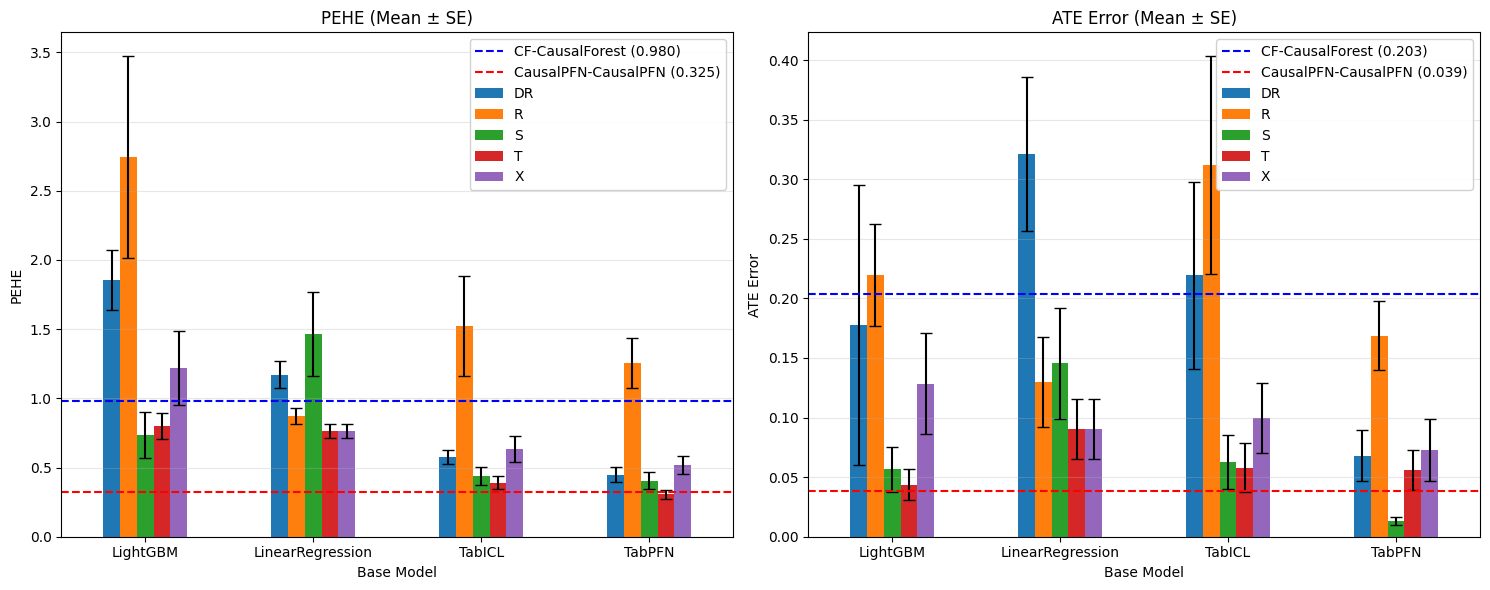

In [9]:

# Aggregate results
summary_rows = []

HPO_LEARNERS = ['S', 'T', 'X']  # meta-learners that have TabPFN-HPO

for meta in ['S', 'T', 'X', 'R', 'DR', 'CF', 'CausalPFN']:
    if meta == 'CausalPFN':
        models = ['CausalPFN']
    elif meta == 'CF':
        models = ['CausalForest']
    else:
        base_models = ['LinearRegression', 'LightGBM', 'TabPFN', 'TabICL']
        hpo = ['TabPFN-HPO'] if meta in HPO_LEARNERS else []
        models = base_models + hpo

    for model in models:
        pehes = all_results[meta][model]['pehe']
        ate_errs = all_results[meta][model]['ate_error']

        if not pehes:
            continue

        n = len(pehes)
        summary_rows.append({
            'Meta-Learner': meta,
            'Base Model': model,
            'PEHE Mean': np.mean(pehes),
            'PEHE SE': np.std(pehes) / np.sqrt(n),
            'ATE Error Mean': np.mean(ate_errs),
            'ATE Error SE': np.std(ate_errs) / np.sqrt(n)
        })

df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))

# Export to CSV
csv_path = 'benchmark_results_IHDP.csv'
df_summary.to_csv(csv_path, index=False)
print(f"\nResults exported to {csv_path}")

# Visualization
if not df_summary.empty:
    df_meta = df_summary[~df_summary['Meta-Learner'].isin(['CausalPFN', 'CF'])]
    df_standalone = df_summary[df_summary['Meta-Learner'].isin(['CausalPFN', 'CF'])]

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    metrics = ['PEHE', 'ATE Error']
    for idx, metric in enumerate(metrics):
        ax = axes[idx]

        if not df_meta.empty:
            plot_data = df_meta.pivot(index='Base Model', columns='Meta-Learner', values=f'{metric} Mean')
            plot_err = df_meta.pivot(index='Base Model', columns='Meta-Learner', values=f'{metric} SE')
            plot_data.plot(kind='bar', yerr=plot_err, ax=ax, capsize=4, rot=0, legend=False)

        for _, row in df_standalone.iterrows():
            val = row[f'{metric} Mean']
        
            # Assign colors
            if row['Meta-Learner'] == 'CausalPFN':
                color = 'red'
            elif row['Meta-Learner'] == 'CF':
                color = 'blue'
            else:
                color = 'black'  # fallback (just in case)
        
            ax.axhline(
                y=val,
                linestyle='--',
                linewidth=1.5,
                color=color,
                label=f"{row['Meta-Learner']}-{row['Base Model']} ({val:.3f})"
            )

        ax.set_title(f'{metric} (Mean \u00b1 SE)')
        ax.set_ylabel(metric)
        ax.grid(True, alpha=0.3, axis='y')
        ax.legend(loc='upper right', framealpha=0.9)

    plt.tight_layout()
    plt.savefig("resultsihdp_plot.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No results to plot.")


In [8]:
# Create a ranking leaderboard for top 5 performers
print("=" * 80)
print(" " * 25 + "LEADERBOARD - TOP 5 PERFORMERS")
print("=" * 80)
print()

# Rank by PEHE (lower is better)
df_ranked_pehe = df_summary.sort_values('PEHE Mean').reset_index(drop=True)
df_ranked_pehe['Rank'] = df_ranked_pehe.index + 1

# Rank by ATE Error (lower is better)
df_ranked_ate = df_summary.sort_values('ATE Error Mean').reset_index(drop=True)
df_ranked_ate['Rank'] = df_ranked_ate.index + 1

# Display PEHE Rankings
print("PRECISION IN ESTIMATING HETEROGENEOUS EFFECTS (PEHE)")
print("   Lower is Better - Measures Individual Treatment Effect Accuracy")
print("-" * 80)
for idx, row in df_ranked_pehe.head(5).iterrows():
    rank = idx + 1
    model_name = f"{row['Meta-Learner']}-{row['Base Model']}"
    pehe_score = row['PEHE Mean']
    pehe_se = row['PEHE SE']
    
    print(f"{rank}. {model_name:30s}  PEHE: {pehe_score:6.4f} +/- {pehe_se:5.4f}")

print()
print("=" * 80)
print()

# Display ATE Error Rankings
print("AVERAGE TREATMENT EFFECT ESTIMATION (ATE Error)")
print("   Lower is Better - Measures Population-Level Treatment Effect Accuracy")
print("-" * 80)
for idx, row in df_ranked_ate.head(5).iterrows():
    rank = idx + 1
    model_name = f"{row['Meta-Learner']}-{row['Base Model']}"
    ate_score = row['ATE Error Mean']
    ate_se = row['ATE Error SE']
    
    print(f"{rank}. {model_name:30s}  ATE Error: {ate_score:6.4f} +/- {ate_se:5.4f}")

print()
print("=" * 80)
print()

# Overall winner (combining both metrics with equal weights)
# Normalize scores to 0-1 range and combine
pehe_scores = df_summary['PEHE Mean'].values
ate_scores = df_summary['ATE Error Mean'].values

pehe_normalized = (pehe_scores - pehe_scores.min()) / (pehe_scores.max() - pehe_scores.min())
ate_normalized = (ate_scores - ate_scores.min()) / (ate_scores.max() - ate_scores.min())

df_summary['Combined Score'] = (pehe_normalized + ate_normalized) / 2
df_ranked_overall = df_summary.sort_values('Combined Score').reset_index(drop=True)

print("OVERALL CHAMPION (Combined PEHE + ATE Performance)")
print("-" * 80)
winner = df_ranked_overall.iloc[0]
winner_name = f"{winner['Meta-Learner']}-{winner['Base Model']}"
print(f"Winner: {winner_name}")
print(f"   PEHE: {winner['PEHE Mean']:.4f} +/- {winner['PEHE SE']:.4f}")
print(f"   ATE Error: {winner['ATE Error Mean']:.4f} +/- {winner['ATE Error SE']:.4f}")
print()
print("=" * 80)

                         LEADERBOARD - TOP 5 PERFORMERS

PRECISION IN ESTIMATING HETEROGENEOUS EFFECTS (PEHE)
   Lower is Better - Measures Individual Treatment Effect Accuracy
--------------------------------------------------------------------------------
1. T-TabPFN                        PEHE: 0.3052 +/- 0.0332
2. CausalPFN-CausalPFN             PEHE: 0.3247 +/- 0.0571
3. T-TabICL                        PEHE: 0.3914 +/- 0.0501
4. S-TabPFN                        PEHE: 0.4048 +/- 0.0621
5. S-TabICL                        PEHE: 0.4388 +/- 0.0674


AVERAGE TREATMENT EFFECT ESTIMATION (ATE Error)
   Lower is Better - Measures Population-Level Treatment Effect Accuracy
--------------------------------------------------------------------------------
1. S-TabPFN                        ATE Error: 0.0129 +/- 0.0032
2. CausalPFN-CausalPFN             ATE Error: 0.0387 +/- 0.0170
3. T-LightGBM                      ATE Error: 0.0435 +/- 0.0131
4. T-TabPFN                        ATE Error: 0.056